# Schematic figures G3, G6, G7

Generates publication-style **diagrams** (no data required):

- **G3** — Frozen pathology encoder + trainable linear head (Virchow2-style).
- **G6** — Bootstrap confidence intervals and paired permutation tests on the **same** fixed test patches.
- **G7** — Qualitative error-pool buckets and checklist review workflow.

**Outputs** (under `reports/figures/`):

- `figure_schematic_g3_frozen_encoder_head.png` / `.pdf`
- `figure_schematic_g6_bootstrap_paired_permutation.png` / `.pdf`
- `figure_schematic_g7_qualitative_review_buckets.png` / `.pdf`

Run all cells from repo root or from `notebooks/` (paths auto-resolve).

In [11]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

_cwd = Path.cwd().resolve()
REPO = _cwd if (_cwd / "reports").is_dir() else _cwd.parent
if not (REPO / "reports").is_dir():
    REPO = Path(r"C:\GP_ECG")

FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DPI = 300


def save_fig(stem: str) -> None:
    base = FIG_DIR / stem
    plt.savefig(base.with_suffix(".png"), dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.savefig(base.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
    print("Wrote", base.with_suffix(".png"), "and .pdf")


print("REPO:", REPO)
print("FIG_DIR:", FIG_DIR)

REPO: C:\GP_ECG
FIG_DIR: C:\GP_ECG\reports\figures


## G3 — Frozen encoder + trainable head

Place in **Theoretical Background** → *Frozen-encoder transfer learning*.

Wrote C:\GP_ECG\reports\figures\figure_schematic_g3_frozen_encoder_head.png and .pdf


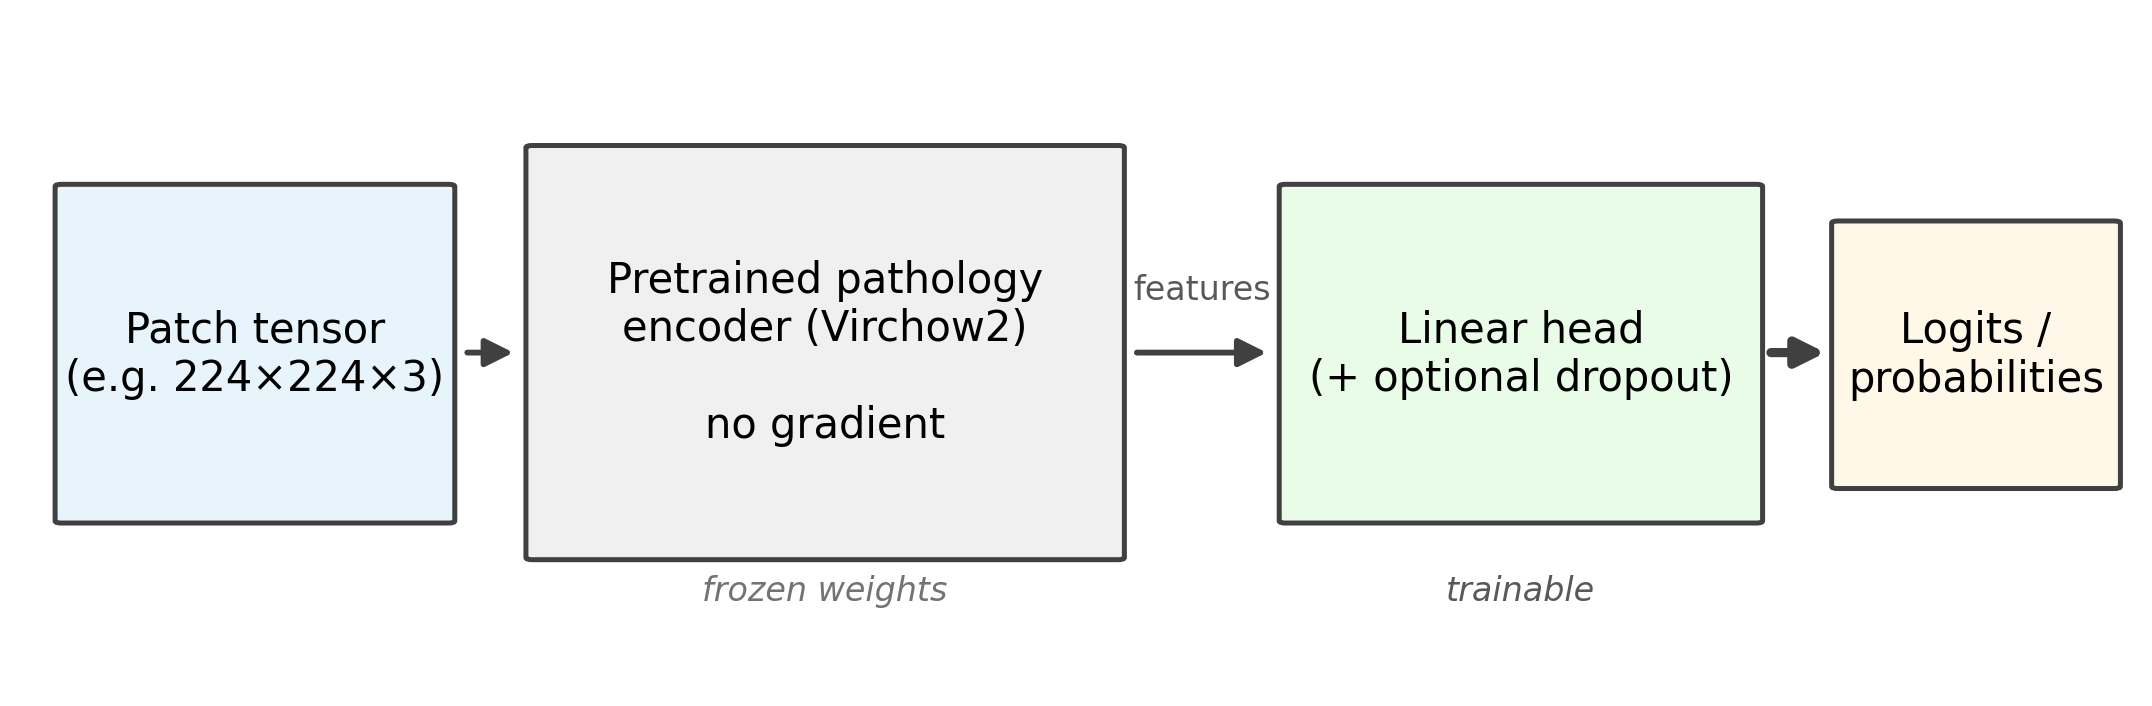

In [12]:
def draw_g3() -> None:
    fig, ax = plt.subplots(figsize=(9, 2.8), dpi=DPI)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 3)
    ax.axis("off")

    def box(x, y, w, h, text, fc, ec="0.25", lw=1.2, fs=10, style="round,pad=0.03"):
        p = FancyBboxPatch(
            (x, y), w, h, boxstyle=style, linewidth=lw, edgecolor=ec, facecolor=fc, mutation_aspect=0.35
        )
        ax.add_patch(p)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, wrap=True)

    def arrow(x1, y1, x2, y2, text=None, lw=1.4, z=2):
        arr = FancyArrowPatch(
            (x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=14, linewidth=lw, color="0.25", zorder=z
        )
        ax.add_patch(arr)
        if text:
            ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.25, text, ha="center", fontsize=8, color="0.35")

    # Input
    box(0.15, 0.72, 1.85, 1.55, "Patch tensor\n(e.g. 224×224×3)", "#e8f4fc")
    arrow(2.05, 1.5, 2.35, 1.5)

    # Encoder frozen
    box(2.4, 0.55, 2.8, 1.9, "Pretrained pathology\nencoder (Virchow2)\n\nno gradient", "#f0f0f0")
    ax.text(3.8, 0.35, "frozen weights", ha="center", fontsize=8, style="italic", color="0.45")
    arrow(5.25, 1.5, 5.95, 1.5, "features")

    # Head trainable
    box(6.0, 0.72, 2.25, 1.55, "Linear head\n(+ optional dropout)", "#e8fce8")
    ax.text(7.125, 0.35, "trainable", ha="center", fontsize=8, style="italic", color="0.35")
    # Head ends at x=8.25; leave a visible shaft before logits box
    arrow(8.28, 1.5, 8.62, 1.5, lw=2.2, z=5)

    box(8.64, 0.88, 1.32, 1.22, "Logits /\nprobabilities", "#fff8e8")


draw_g3()
save_fig("figure_schematic_g3_frozen_encoder_head")
plt.show()

## G6 — Bootstrap intervals and paired permutation

Place in **Methodology** → *Statistical analysis*.

Wrote C:\GP_ECG\reports\figures\figure_schematic_g6_bootstrap_paired_permutation.png and .pdf


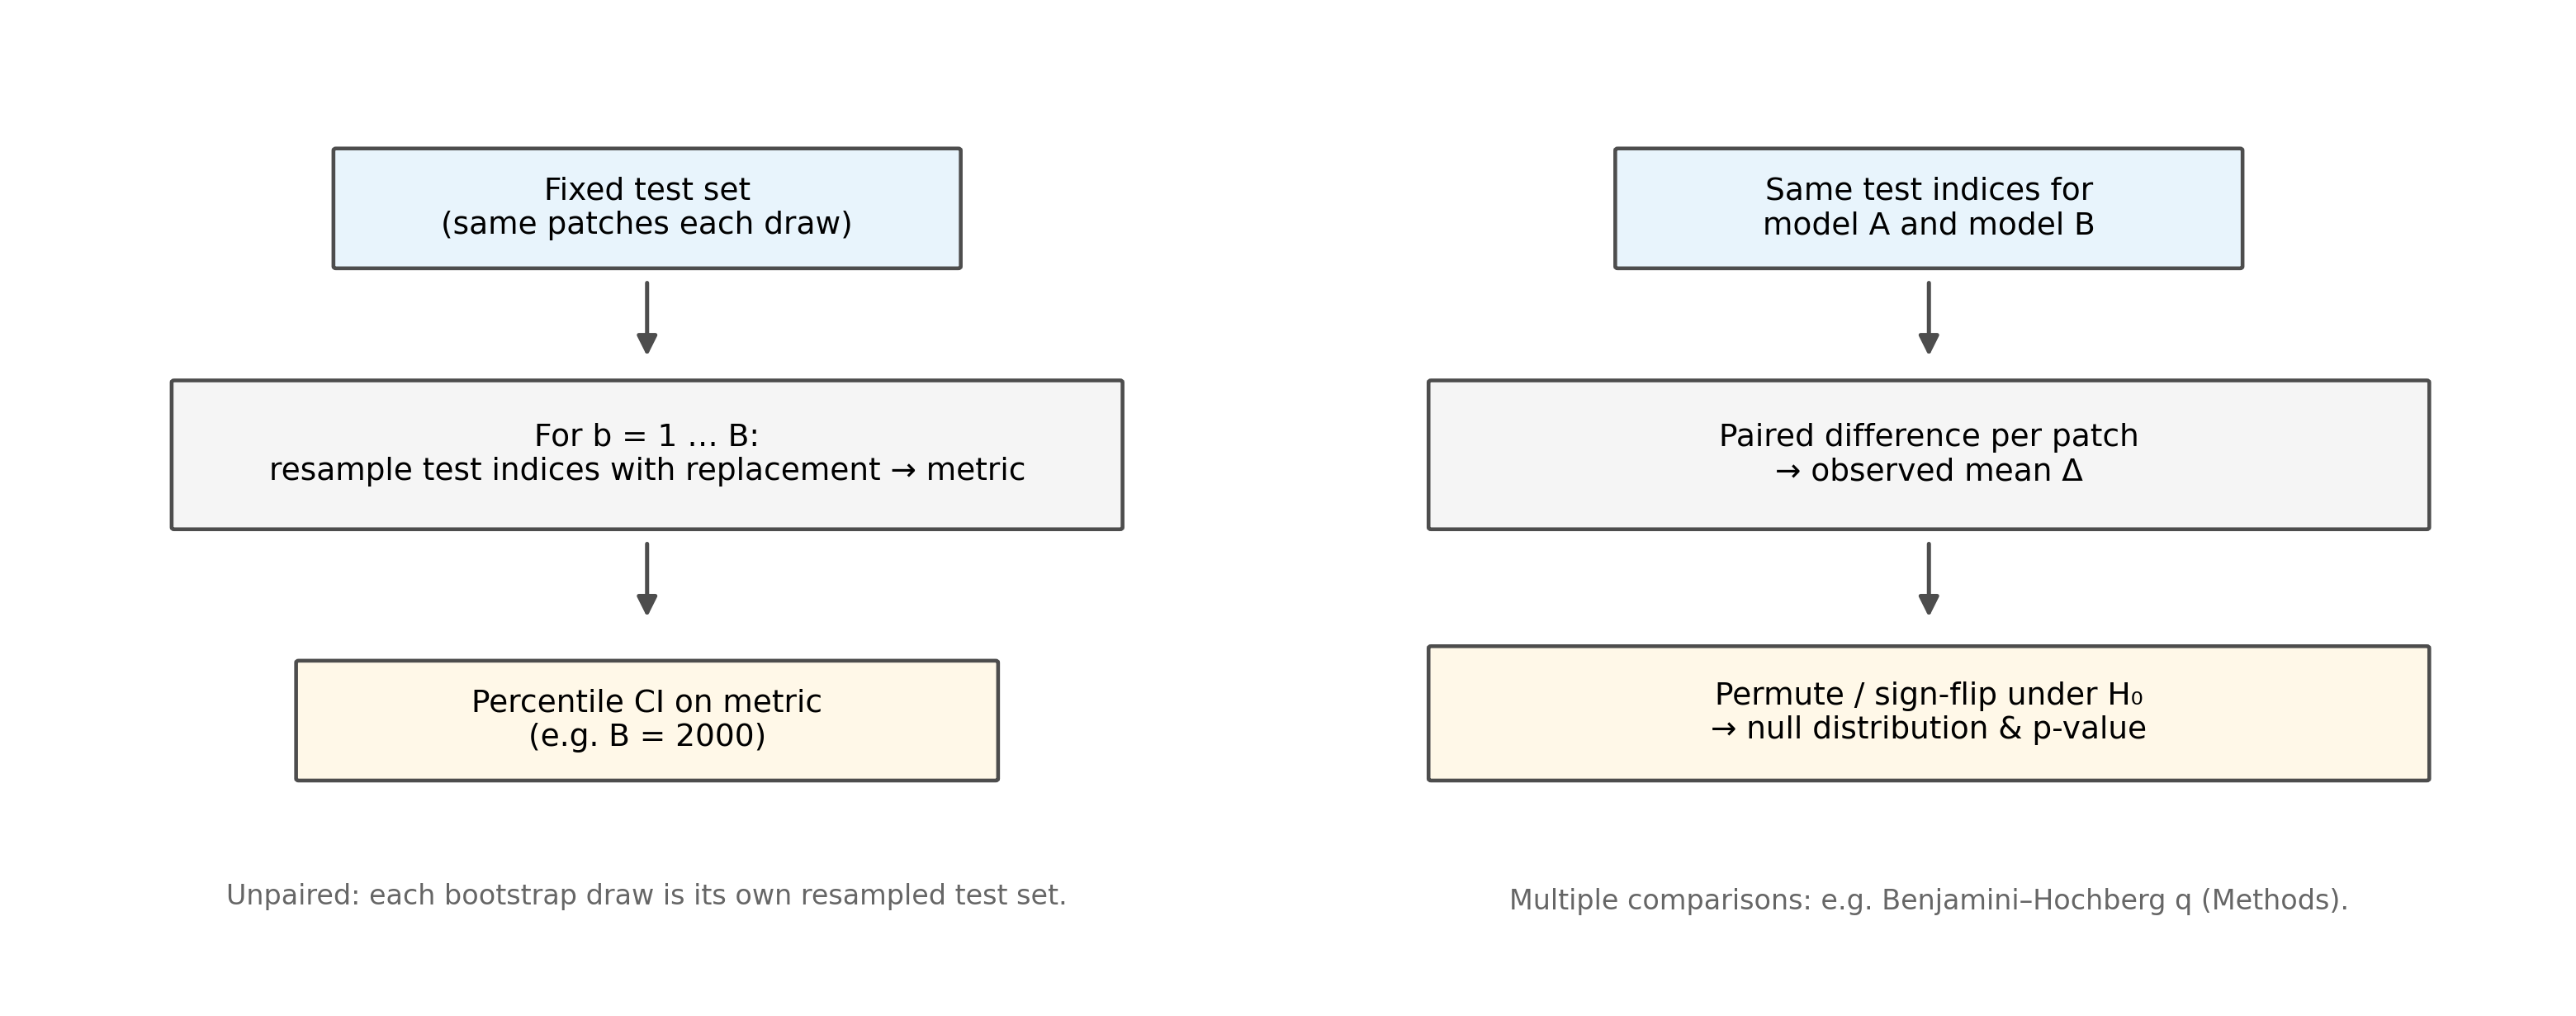

In [13]:
def draw_g6() -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2), dpi=DPI)

    for ax in (ax1, ax2):
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.axis("off")

    def bbox(ax, x, y, w, h, text, fc):
        p = FancyBboxPatch(
            (x, y), w, h, boxstyle="round,pad=0.02", linewidth=1.1, edgecolor="0.3", facecolor=fc
        )
        ax.add_patch(p)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9)

    def arr(ax, x1, y1, x2, y2):
        ax.add_patch(
            FancyArrowPatch(
                (x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=12, linewidth=1.2, color="0.3"
            )
        )

    # Panel (a)
    bbox(ax1, 2.5, 7.5, 5, 1.2, "Fixed test set\n(same patches each draw)", "#e8f4fc")
    arr(ax1, 5, 7.4, 5, 6.5)
    bbox(ax1, 1.2, 4.8, 7.6, 1.5, "For b = 1 … B:\nresample test indices with replacement → metric", "#f5f5f5")
    arr(ax1, 5, 4.7, 5, 3.8)
    bbox(ax1, 2.2, 2.2, 5.6, 1.2, "Percentile CI on metric\n(e.g. B = 2000)", "#fff8e8")
    ax1.text(5, 0.9, "Unpaired: each bootstrap draw is its own resampled test set.", ha="center", fontsize=8, color="0.4")

    # Panel (b)
    bbox(ax2, 2.5, 7.5, 5, 1.2, "Same test indices for\nmodel A and model B", "#e8f4fc")
    arr(ax2, 5, 7.4, 5, 6.5)
    bbox(ax2, 1.0, 4.8, 8.0, 1.5, "Paired difference per patch\n→ observed mean Δ", "#f5f5f5")
    arr(ax2, 5, 4.7, 5, 3.8)
    bbox(ax2, 1.0, 2.2, 8.0, 1.35, "Permute / sign-flip under H₀\n→ null distribution & p-value", "#fff8e8")
    ax2.text(
        5,
        0.85,
        "Multiple comparisons: e.g. Benjamini–Hochberg q (Methods).",
        ha="center",
        fontsize=8,
        color="0.4",
    )

    fig.tight_layout()


draw_g6()
save_fig("figure_schematic_g6_bootstrap_paired_permutation")
plt.show()

## G7 — Qualitative review buckets

Place in **Methodology** → *Qualitative analysis* or **Results** → *Qualitative error analysis*.

Wrote C:\GP_ECG\reports\figures\figure_schematic_g7_qualitative_review_buckets.png and .pdf


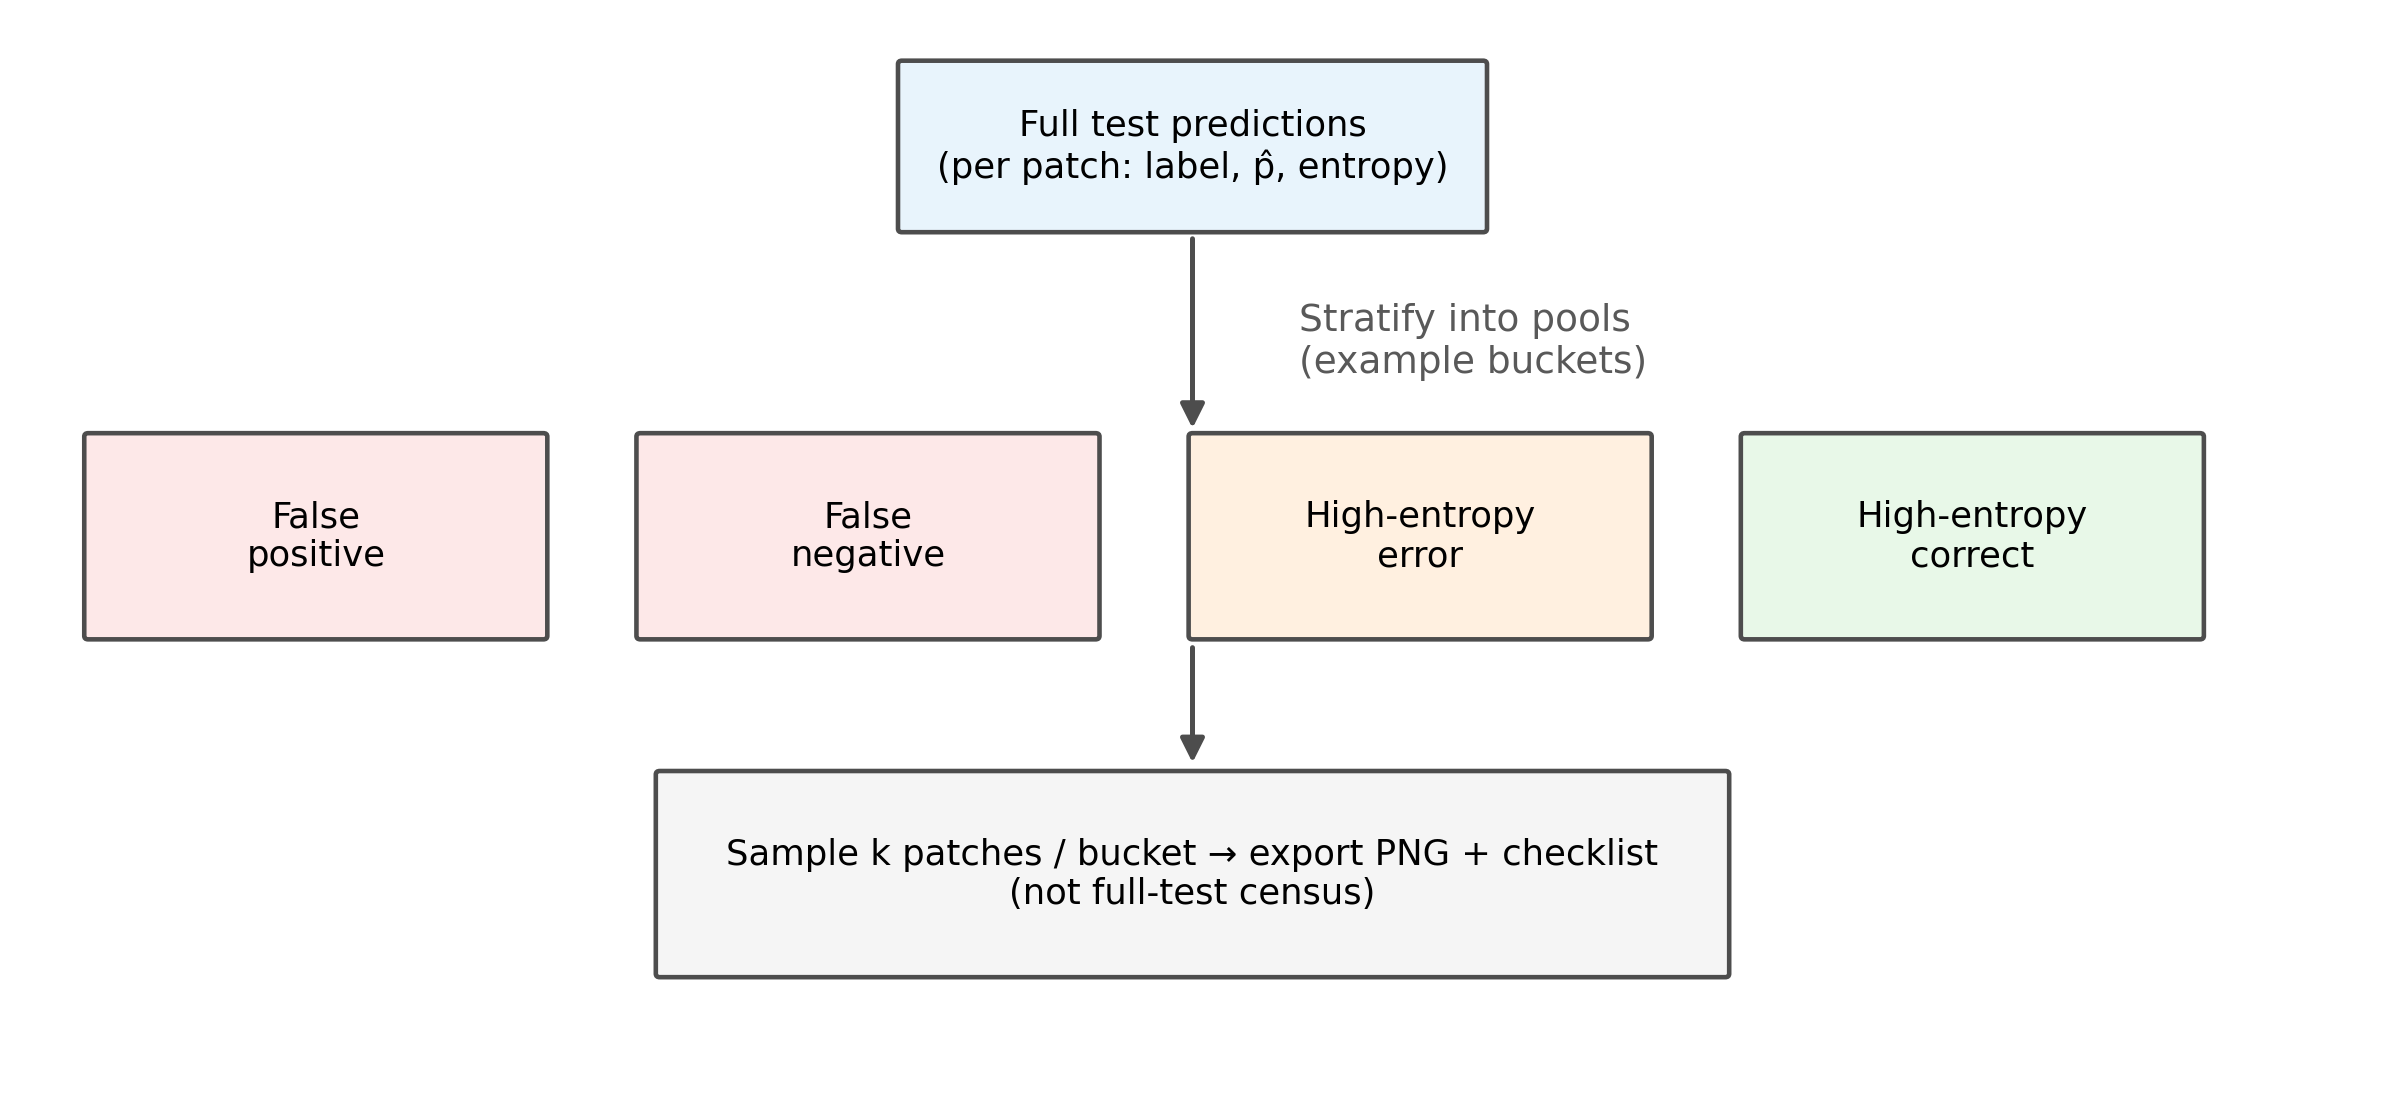

In [ ]:
def draw_g7() -> None:
    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=DPI)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6)
    ax.axis("off")

    def box(x, y, w, h, text, fc):
        p = FancyBboxPatch(
            (x, y), w, h, boxstyle="round,pad=0.02", linewidth=1.1, edgecolor="0.3", facecolor=fc
        )
        ax.add_patch(p)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=8.5)

    def arrow(x1, y1, x2, y2):
        ax.add_patch(
            FancyArrowPatch(
                (x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=12, linewidth=1.2, color="0.3"
            )
        )

    box(4.5, 4.85, 3.0, 0.95, "Full test predictions\n(per patch: label, p̂, entropy)", "#e8f4fc")
    arrow(6, 4.84, 6, 3.65)

    ax.text(6.55, 4.2, "Stratify into pools\n(example buckets)", ha="left", va="center", fontsize=9, color="0.35")

    buckets = [
        (0.3, 2.5, "False\npositive", "#fde8e8"),
        (3.15, 2.5, "False\nnegative", "#fde8e8"),
        (6.0, 2.5, "High-entropy\nerror", "#fff0e0"),
        (8.85, 2.5, "High-entropy\ncorrect", "#e8f8e8"),
    ]
    for (x, y, lab, fc) in buckets:
        box(x, y, 2.35, 1.15, lab, fc)

    arrow(6, 2.48, 6, 1.72)
    box(3.25, 0.55, 5.5, 1.15, "Sample k patches / bucket → export PNG + checklist\n(not full-test census)", "#f5f5f5")


draw_g7()
save_fig("figure_schematic_g7_qualitative_review_buckets")
plt.show()